ВАРИАНТ 1

In [112]:
import pandas as pd
import numpy as np
from tensorflow import keras
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [113]:
def plot_bin_clasifer(x, y, X_test, Y_test, X_train, Y_train, Y_pred, w):
    """Отрисовка классов бинарной классификации для Keras"""
    
    plt.figure(figsize=(10, 6))
    x = x.to_numpy()  # Преобразуем DataFrame в NumPy

    #  Отображение точек обучающей выборки

    plt.scatter(x[y == 0, 0], x[y == 0, 1],
                c='blue', label='Класс 0 (train)', alpha=0.6, 
                edgecolors='black', s=50)
    plt.scatter(x[y == 1, 0], x[y == 1, 1],
                c='red', label='Класс 1 (train)', alpha=0.6, 
                edgecolors='black', s=50)   
    
    # #  Отображение точек обучающей выборки

    # plt.scatter(X_train[Y_train == 0, 0], X_train[Y_train == 0, 1],
    #             c='blue', label='Класс 0 (train)', alpha=0.6, 
    #             edgecolors='black', s=50)
    # plt.scatter(X_train[Y_train == 1, 0], X_train[Y_train == 1, 1],
    #             c='red', label='Класс 1 (train)', alpha=0.6, 
    #             edgecolors='black', s=50)    
    #  Отображение точек тестовой выборки (крестиками)
    plt.scatter(X_test[Y_pred == 0, 0], X_test[Y_pred == 0, 1],
                c='blue', marker='x', s=100, linewidths=2, 
                label='Класс 0 (test)')
    plt.scatter(X_test[Y_pred == 1, 0], X_test[Y_pred == 1, 1],
                c='red', marker='x', s=100, linewidths=2, 
                label='Класс 1 (test)')
    
    


    print(f'Веса модели: w1={w[0][0][0]}, w2={w[0][1][0]}, w0={w[1][0]}')

    #w1=0.5524189472198486, w2=-0.4298827350139618, w0=2.4790706634521484
    #  Построение линии разделения
    # Формула: w0 + w1*x1 + w2*x2 = 0
    # Отсюда: x2 = -(w0 + w1*x1) / w2
    decision_boundary = -(w[1][0] + w[0][0][0] * x) / w[0][1][0]
    plt.plot(x, decision_boundary, color='green' ,
             label='Граница решения')
    
    #  Оформление графика
    plt.xlabel('x₁', fontsize=12)
    plt.ylabel('x₂', fontsize=12)
    plt.title('Decision Boundary (Логистическая регрессия Keras)', fontsize=14)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    


In [114]:
data1 = pd.read_csv('task11.csv')
data2 = pd.read_csv('task21.csv')
features = data1.drop(columns=['target'])
label = data1['target']

In [115]:
# Разделение на выборки
X_train, X_test, Y_train, Y_test = train_test_split(
    features.values, label.values, 
    test_size=0.2, 

)

print(f"\nОбучающая выборка: {len(X_train)} точек")
print(f"Тестовая выборка: {len(X_test)} точек")
X_train
Y_test


Обучающая выборка: 320 точек
Тестовая выборка: 80 точек


array([0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0,
       1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1])

Конструируем полносвязную сеть

In [116]:
model = keras.models.Sequential()

Добавляем в модель входной слой, состоящий из двух входов
Добавляем в модель глубинный слой (т е лежащий послевходного), состоящий из одного нейрона, у которого сигмоидальная функция активации

In [117]:
model.add(keras.layers.InputLayer(shape=(2,)))
model.add(keras.layers.Dense(1,activation='sigmoid'))

«Компилируем» модель, объединяя в одно целое слои, оптимизатор и функцию потерь

In [118]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
              #binary_crossentropy имя логарифмической функции потерь
              loss=keras.losses.binary_crossentropy,
              #BinaryAccuracy — это специализированная метрика для бинарной классификации 
              metrics= [keras.metrics.BinaryAccuracy])

Обучение модели 

In [119]:
print('Начало обучения модели...')
model.fit(X_train, Y_train, batch_size=1, epochs= 100, verbose=1)
print('Модель обучилась!')

Начало обучения модели...
Epoch 1/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - binary_accuracy: 0.4906 - loss: 7.7615
Epoch 2/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.4906 - loss: 4.4538
Epoch 3/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.4906 - loss: 1.5256
Epoch 4/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.7219 - loss: 0.6043
Epoch 5/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.8219 - loss: 0.5152
Epoch 6/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.8719 - loss: 0.4568
Epoch 7/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.8813 - loss: 0.4077
Epoch 8/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.9094 - loss: 0.3664
Epoch 9/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.9250 - loss: 0.3321
Epoch 10/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.9438 - loss: 0.3028
Epoch 11/100
320/320 ━━━━━━━━━━━━

Видим степень уверенности модели в том, что конкретный тестовый пример принадлежит классу с маркером 1

In [120]:
y_pred = model.predict(X_test)
y_pred = y_pred.flatten()
print(y_pred)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
[1.74119894e-03 1.06544618e-03 9.99513209e-01 1.08956555e-02
 9.95758965e-05 9.99843597e-01 1.23484749e-02 1.24019885e-03
 9.72501397e-01 1.13868741e-02 1.78818777e-03 9.99973178e-01
 1.13403052e-03 9.98417377e-01 9.92741942e-01 9.99324024e-01
 9.29381422e-05 9.99996960e-01 9.99977648e-01 9.98165429e-01
 3.72456349e-02 9.93941963e-01 1.18608195e-02 9.82840434e-02
 8.95697832e-01 4.68595931e-03 3.34233046e-02 5.87148918e-03
 9.90780592e-01 7.25050268e-05 2.99164057e-01 9.99993205e-01
 7.74334073e-01 1.96557515e-03 7.71215418e-04 9.95572865e-01
 9.99308467e-01 4.00885902e-02 9.99638319e-01 1.78654923e-03
 1.12648189e-01 9.99615788e-01 9.98332322e-01 1.08278068e-02
 9.68008578e-01 4.29181819e-04 9.99975920e-01 2.08530739e-01
 2.79238671e-01 1.75246591e-04 4.34864014e-01 9.91953731e-01
 8.21358144e-01 7.76136935e-01 9.99992013e-01 2.84705788e-01
 4.44502443e-01 5.87994233e-04 9.10875022e-01 1.42431376e-03
 1.70700339e-04 1.89697146e-01 9.98387396e-01 7

In [121]:
m1 = np.round(y_pred.T[0],0).astype(np.int32)
m2 = np.array(Y_test)
m2.shape
m1.shape
print('Количество ошибочных классификаций: ', sum(abs(m1-m2)))
y_pred = np.round(y_pred)

Количество ошибочных классификаций:  37


In [122]:
w = model.layers[0].get_weights()
print(f'w1={w[0][0][0]}, w2={w[0][1][0]}, w1={w[1][0]}')
w

w1=1.1184099912643433, w2=-1.2262436151504517, w1=-2.9924330711364746


[array([[ 1.11841  ],
        [-1.2262436]], dtype=float32),
 array([-2.992433], dtype=float32)]

Веса модели: w1=1.1184099912643433, w2=-1.2262436151504517, w0=-2.9924330711364746


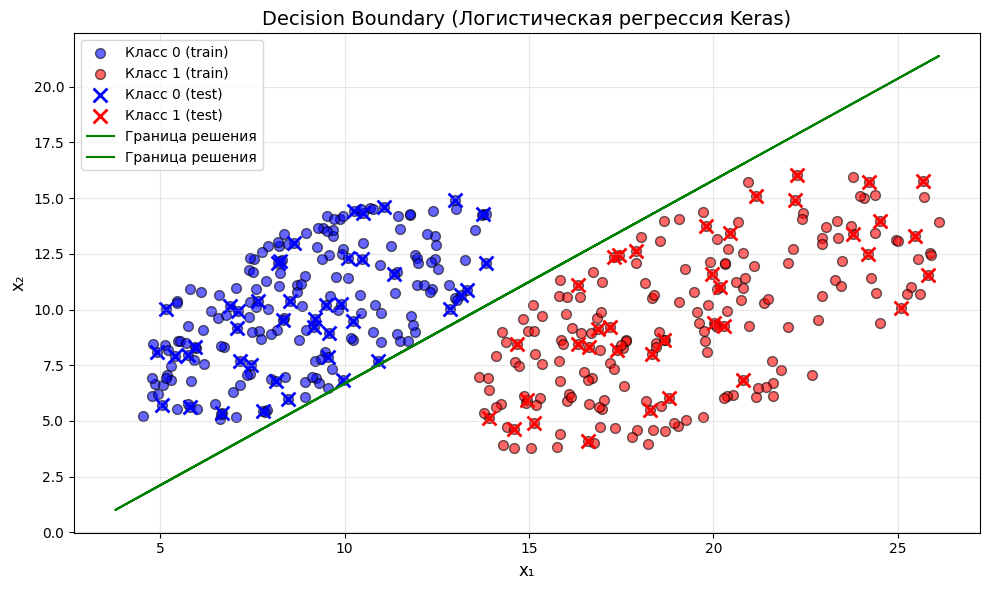

In [123]:
plot_bin_clasifer(features, label, X_test, Y_test, X_train, Y_train, y_pred,w)

In [124]:
features = data2.drop(columns=['target'])
label = data2['target']
# Разделение на выборки
X_train, X_test, Y_train, Y_test = train_test_split(
    features.values, label.values, 
    test_size=0.2, 
)

In [125]:
print(f"\nОбучающая выборка: {len(X_train)} точек")
print(f"Тестовая выборка: {len(X_test)} точек")
X_train


Обучающая выборка: 320 точек
Тестовая выборка: 80 точек


array([[ 4.40983791, 11.9785217 ],
       [ 5.69882047,  8.80135427],
       [ 7.91831093, 11.05948723],
       [ 3.35415283, 17.43861564],
       [ 8.54283471, 11.13004852],
       [ 6.58486594,  9.19297608],
       [ 5.72541215,  7.85150864],
       [ 6.4835287 , 17.12935119],
       [ 3.16824508, 17.77103182],
       [ 6.76336099, 16.4585762 ],
       [ 3.48306327, 16.83704209],
       [ 4.27627424, 12.03563195],
       [ 6.72318049, 16.45582967],
       [ 4.66471882, 17.86439676],
       [ 3.94034671,  7.82778569],
       [ 4.81135861,  9.63554389],
       [ 6.64132406, 12.2916667 ],
       [ 4.18537482, 12.55500974],
       [ 5.54360375, 16.66447124],
       [ 4.27741364, 17.89162237],
       [ 6.00046438,  8.8065184 ],
       [ 5.7174001 , 12.98949143],
       [ 8.53281787,  6.8754808 ],
       [ 5.75809562, 15.79382922],
       [ 5.82576976, 17.75104005],
       [ 8.20646685,  8.9110472 ],
       [ 2.62910042, 10.51431228],
       [ 4.33217638, 14.38862355],
       [ 5.85546822,

In [126]:
model = keras.models.Sequential()
model.add(keras.layers.InputLayer(shape=(2,)))
model.add(keras.layers.Dense(1,activation='sigmoid'))

In [127]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
              #binary_crossentropy имя логарифмической функции потерь
              loss=keras.losses.binary_crossentropy,
              #BinaryAccuracy — это специализированная метрика для бинарной классификации 
              metrics= [keras.metrics.BinaryAccuracy])

In [132]:
print('Начало обучения модели...')
model.fit(X_train, Y_train, batch_size=1, epochs= 1000, verbose=1)
print('Модель обучилась!')

Начало обучения модели...
Epoch 1/1000
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.8469 - loss: 0.3008
Epoch 2/1000
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.8500 - loss: 0.2993
Epoch 3/1000
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.8594 - loss: 0.2990
Epoch 4/1000
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.8562 - loss: 0.2972
Epoch 5/1000
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.8469 - loss: 0.2954
Epoch 6/1000
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.8594 - loss: 0.2955
Epoch 7/1000
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.8594 - loss: 0.2945
Epoch 8/1000
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.8656 - loss: 0.2939
Epoch 9/1000
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.8625 - loss: 0.2923
Epoch 10/1000
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.8719 - loss: 0.2925
Epoch 11/1000
320/320 ━

In [133]:
y_pred = model.predict(X_test)
print(y_pred)
m1 = np.round(y_pred.T[0],0).astype(np.int32)
m2 = np.array(Y_test)
m2.shape
m1.shape
print('Количество ошибочных классификаций: ', sum(abs(m1-m2)))
y_pred = y_pred.flatten()
y_pred = np.round(y_pred)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
[[9.5665336e-01]
 [9.9107128e-01]
 [9.5298636e-01]
 [6.1590143e-04]
 [9.9970812e-01]
 [2.3230931e-02]
 [2.9277518e-02]
 [1.8549273e-02]
 [7.9179868e-02]
 [9.9873447e-01]
 [1.5480727e-01]
 [9.0515196e-01]
 [9.9516720e-01]
 [9.9932343e-01]
 [4.3921322e-02]
 [4.8764236e-03]
 [2.8224145e-03]
 [9.8096740e-01]
 [9.9850643e-01]
 [3.7304107e-03]
 [9.5207870e-01]
 [1.5200667e-01]
 [1.1034973e-03]
 [6.5302434e-03]
 [4.5035118e-03]
 [9.8858601e-01]
 [1.9273950e-02]
 [9.9906343e-01]
 [9.9930251e-01]
 [8.0694741e-01]
 [9.9701273e-01]
 [9.9725515e-01]
 [6.0750160e-02]
 [2.8771520e-04]
 [1.1434741e-02]
 [6.8141501e-03]
 [3.3070394e-03]
 [9.9981350e-01]
 [9.3281915e-04]
 [7.0075405e-01]
 [9.9912471e-01]
 [9.9225648e-02]
 [1.2638994e-03]
 [9.9217218e-01]
 [8.4888638e-04]
 [8.7521031e-02]
 [9.9772829e-01]
 [9.8014545e-01]
 [2.3291642e-02]
 [2.4751648e-03]
 [1.5742229e-01]
 [9.9704665e-01]
 [5.0225449e-01]
 [9.9974483e-01]
 [9.9863994e-01]
 [5.5028975e-01]
 [9.975660

In [134]:
w = model.layers[0].get_weights()
print(f'w1={w[0][0][0]}, w2={w[0][1][0]}, w0={w[1][0]}')
w
#Веса модели: w1=1.3499916791915894, w2=-1.4808846712112427, w0=-3.552701473236084


w1=-0.2742573320865631, w2=-1.4644471406936646, w0=20.630752563476562


[array([[-0.27425733],
        [-1.4644471 ]], dtype=float32),
 array([20.630753], dtype=float32)]

Веса модели: w1=-0.2742573320865631, w2=-1.4644471406936646, w0=20.630752563476562


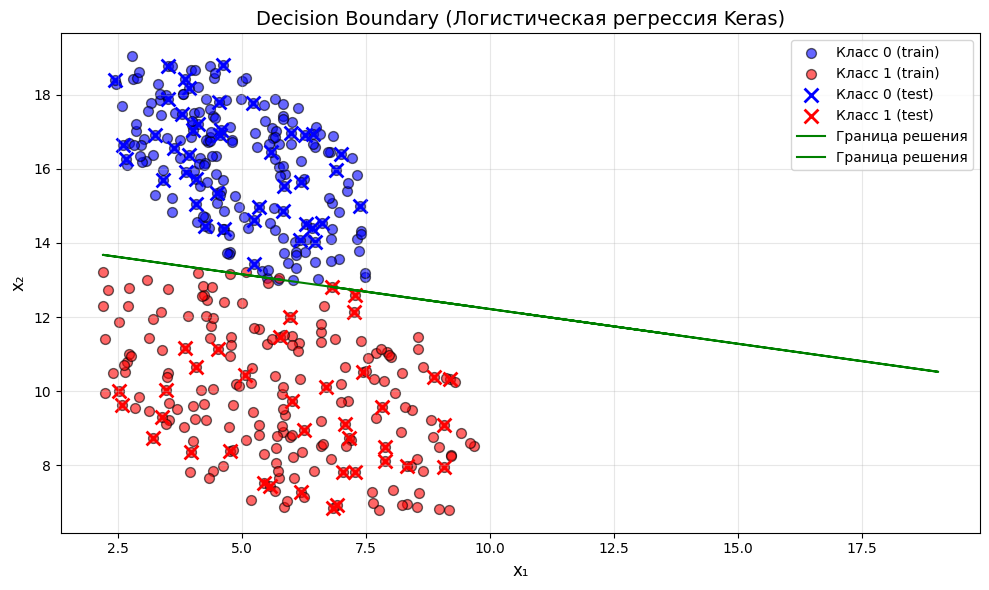

In [135]:
plot_bin_clasifer(features, label, X_test, Y_test, X_train, Y_train, y_pred,w)